<h1><font color = 'Green'> <center>GIS Apps in Engineering: Assignment-9</h1>
<h3><font color = 'blue'> <center>Washemuzzaman Lajuk</h3>

## Workflow  

**Step 1:** Get Data (PCS)  
**Step 2:** Variogram Cloud  
**Step 3:** Empirical Semi-Variogram  
**Step 4:** Fit the Semi-Variogram  
**Step 5:** Select Best Semi-Variogram  
**Step 6:** Create a Grid of Points  
**Step 7:** Use Theoretical Semi-Variogram (TSV) to Predict  
**Step 8:** Calculate Variance (Square Root)  
**Step 9:** Make Plots  
**Step 10:** Embellish  

#### *Provided by - Dr. Uddameri*


In [2]:
# Import Required Libraries

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from scipy.spatial import cKDTree
from matplotlib_map_utils.core.north_arrow import north_arrow
from skgstat import Variogram
from matplotlib_scalebar.scalebar import ScaleBar
from pykrige.ok import OrdinaryKriging


In [3]:
#Set Working Directory

path = '/Users/washemuzzamanlajuk/Desktop/Fall-2025/GIS/Assignment-8'
os.chdir(path)

In [4]:
# Read GeoPackage Files

LibAEA = gpd.read_file("LibAEA.gpkg")       # County boundary polygon
WellsEC = gpd.read_file("ECAEA.gpkg")       # Wells with EC values
GridS = gpd.read_file("GridS.gpkg")          # GRID Point

In [5]:
LibAEA.head()

,CMPTRL_CNT,DPS_CNTY_N,FIPS_ST_CN,TXDOT_CNTY,TXDOT_DIST,CNTY_NM,CNTY_NBR,DIST_NBR,GID,geometry
0,146,146,48291,146,20,Liberty,146,20,67,"MULTIPOLYGON (((121444.098 824528.903, 121494 ..."


In [6]:
WellsEC.head()

,StateWellNumber,ParameterCode,EC,LatitudeDD,LongitudeDD,County,geometry
0,6048101,94.0,584.0,30.344722,-95.085000,NaN,POINT (87820.815 808066.862)
1,6048102,94.0,566.0,30.344722,-95.085556,NaN,POINT (87767.491 808066.371)
2,6048103,94.0,590.0,30.344445,-95.085000,NaN,POINT (87821.111 808036.101)
3,6048104,94.0,717.0,30.348056,-95.086667,NaN,POINT (87657.265 808435.567)
4,6048106,94.0,301.0,30.345000,-95.087500,NaN,POINT (87580.58 808095.427)


In [7]:
GridS.head()

,id,geometry
0,0,POINT (80072.973 757175.501)
1,1,POINT (80782.629 757175.501)
2,2,POINT (81492.285 757175.501)
3,3,POINT (82201.941 757175.501)
4,4,POINT (82911.596 757175.501)


In [8]:
# CHECK COORDINATE REFERENCE SYSTEMS (CRS) FOR ALL LAYERS

print("LibAEA (Boundary) CRS:", LibAEA.crs)     # Boundary polygon CRS
print("WellsEC (Wells) CRS:", WellsEC.crs)      # Wells CRS
print("GridS (Grid Points) CRS:", GridS.crs)    # Grid points CRS

LibAEA (Boundary) CRS: EPSG:5070
WellsEC (Wells) CRS: EPSG:5070
GridS (Grid Points) CRS: EPSG:5070


In [9]:
# INSTALL SCIKIT-GSTAT LIBRARY 

!pip install scikit-gstat --quiet

In [10]:
# EXTRACT COORDINATES AND EC VALUES FROM WELLS DATA

coords = np.column_stack((WellsEC.geometry.x, WellsEC.geometry.y))   # Extract X and Y coordinates
values = WellsEC["EC"].values                                        # Extract EC values

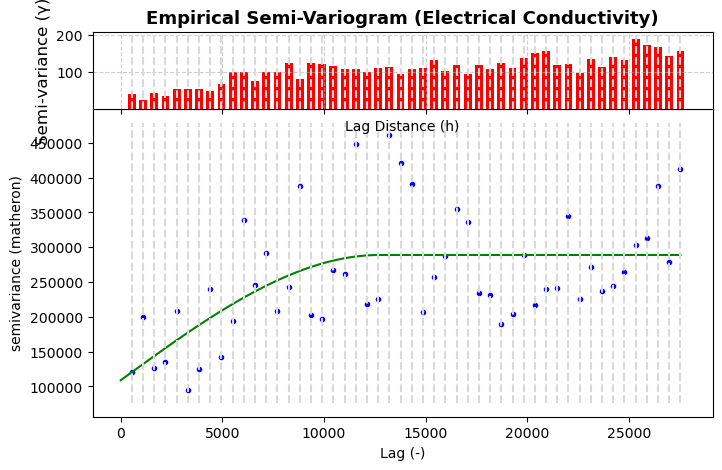

In [11]:
# CREATE VARIOGRAM OBJECT
Vs = Variogram(coordinates=coords,values=values,normalize=False,n_lags=50,maxlag="median", use_nugget=True,  model="spherical")

#PLOT EMPIRICAL SEMI-VARIOGRAM

fig = Vs.plot()       # No 'ax=' argument needed in recent versions
plt.title("Empirical Semi-Variogram (Electrical Conductivity)", fontsize=13, weight='bold')
plt.xlabel("Lag Distance (h)", fontsize=10)
plt.ylabel("Semi-variance (γ)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

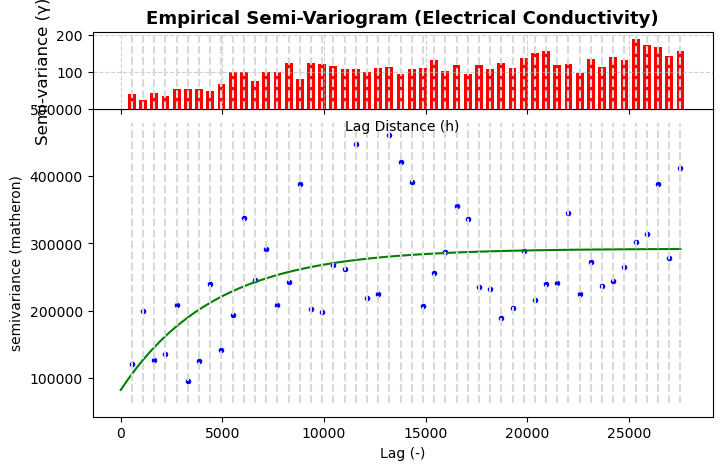

In [12]:
# CREATE VARIOGRAM OBJECT
Vexp = Variogram(coordinates=coords,values=values,normalize=False,n_lags=50,maxlag="median", use_nugget=True,  model="exponential")

#PLOT EMPIRICAL SEMI-VARIOGRAM
fig = Vexp.plot()       # No 'ax=' argument needed in recent versions
plt.title("Empirical Semi-Variogram (Electrical Conductivity)", fontsize=13, weight='bold')
plt.xlabel("Lag Distance (h)", fontsize=10)
plt.ylabel("Semi-variance (γ)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

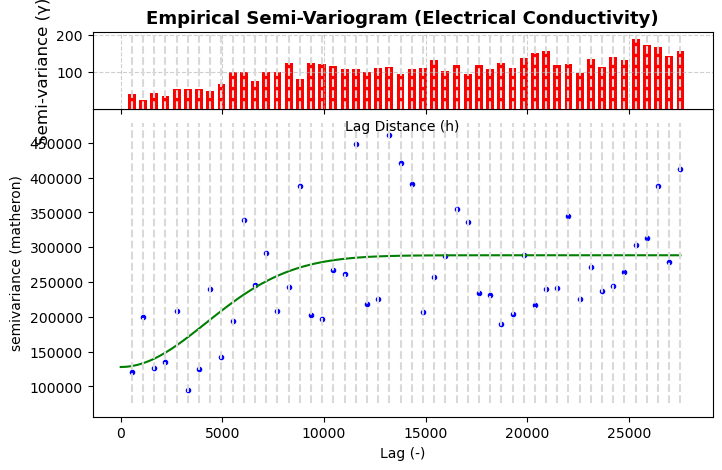

In [13]:
# CREATE VARIOGRAM OBJECT
Vg = Variogram(coordinates=coords,values=values,normalize=False,n_lags=50,maxlag="median", use_nugget=True,  model="gaussian")

#PLOT EMPIRICAL SEMI-VARIOGRAM
fig = Vg.plot()       # No 'ax=' argument needed in recent versions
plt.title("Empirical Semi-Variogram (Electrical Conductivity)", fontsize=13, weight='bold')
plt.xlabel("Lag Distance (h)", fontsize=10)
plt.ylabel("Semi-variance (γ)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

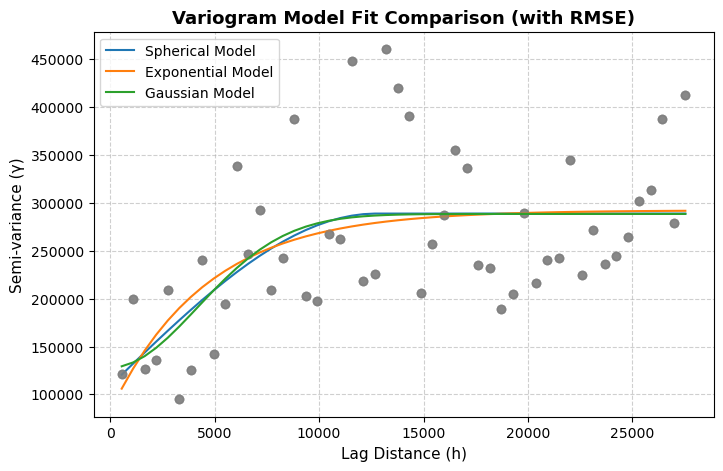

Model fit evaluation:
Spherical    RMSE = 70227.416814
Exponential  RMSE = 71459.210883
Gaussian     RMSE = 70018.454799

 Best-Fit Model: Gaussian (lowest RMSE)


In [14]:
# EVALUATE AND SELECT BEST-FIT VARIOGRAM MODEL

models = ["spherical", "exponential", "gaussian"]       # Candidate variogram models
fit_scores = {}                                         # Dictionary to store RMSE for each model

plt.figure(figsize=(8, 5))                              # Initialize figure for comparison plot

for model in models:
    # CREATE VARIOGRAM OBJECT FOR CURRENT MODEL
    Vmodels = Variogram(coordinates=coords,values=values,normalize=False,n_lags=50,maxlag="median",use_nugget=True,model=model)

    # CALCULATE FITTED VALUES AND RMSE
    YT = Vmodels.experimental                           # Experimental γ values (observed)
    YP = Vmodels.fitted_model(Vmodels.bins)             # Model-predicted γ values (fitted)
    rmse = np.sqrt(np.mean((YT - YP) ** 2))             # Root Mean Square Error
    fit_scores[model] = rmse                            # Store model RMSE

# PLOT EACH MODEL (without RMSE in legend)
    plt.plot(Vmodels.bins, YT, "o", color="gray", alpha=0.6)   # Experimental points
    plt.plot(Vmodels.bins, YP, "-", label=f"{model.title()} Model")               # Fitted model curve

# DISPLAY PLOT
plt.title("Variogram Model Fit Comparison (with RMSE)", fontsize=13, weight="bold")
plt.xlabel("Lag Distance (h)", fontsize=11)
plt.ylabel("Semi-variance (γ)", fontsize=11)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# FIND BEST MODEL (LOWEST RMSE)
BESTMODEL = min(fit_scores, key=fit_scores.get)


print("Model fit evaluation:")
for m, s in fit_scores.items():
    print(f"{m.title():<12} RMSE = {s:.6f}")
print(f"\n Best-Fit Model: {BESTMODEL.title()} (lowest RMSE)")

In [15]:
BESTMODEL

'gaussian'

In [16]:
# EXTRACT PARAMETERS OF THE BEST-FIT VARIOGRAM MODEL

# Create the best-fit Variogram object using the selected model
V = Variogram(coordinates=coords,values=values,normalize=False,n_lags=50,maxlag="median", use_nugget=True,  model=BESTMODEL)


# Extract parameters
nugget = V.parameters[0]             # Nugget (C0)
sill    = V.parameters[1] + nugget   # Total sill (C0 + C1)
range  = V.parameters[2]            # Range (a)

# Display results
print("Best-Fit Variogram Parameters:")
print(f"Model  : {BESTMODEL.title()}")
print(f"Nugget : {nugget:.4f}")
print(f"Sill   : {sill:.4f}")
print(f"Range  : {range:.4f}")

Best-Fit Variogram Parameters:
Model  : Gaussian
Nugget : 11853.2579
Sill   : 172350.3665
Range  : 127947.4464


In [17]:
#INSTALL PYKRIGE LIBRARY

!pip install pykrige --quiet


In [18]:
# APPLY BEST-FIT VARIOGRAM MODEL FOR KRIGING PREDICTION 

# Extract well coordinates and EC values
x = WellsEC.geometry.x.values                              # X-coordinates of wells
y = WellsEC.geometry.y.values                              # Y-coordinates of wells
z = WellsEC["EC"].values                                   # EC (Electrical Conductivity) values

# Extract grid coordinates
xg = GridS.geometry.x.values                               # X-coordinates of grid points
yg = GridS.geometry.y.values                               # Y-coordinates of grid points

# Initialize Ordinary Kriging using the best-fit model parameters
OK = OrdinaryKriging(
    x,                                                     # Sample X-coordinates
    y,                                                     # Sample Y-coordinates
    z,                                                     # EC values
    variogram_model=BESTMODEL,                            # Best-fit variogram model 
    verbose=False, enable_plotting=False
)

# EXECUTE KRIGING INTERPOLATION FOR ALL GRID POINTS
ECP, KV = OK.execute("points", xg, yg)                  # ECP = predicted EC, KV = kriging variance

# CONVERT TO NUMPY ARRAYS FOR FURTHER PROCESSING
ECP = np.array(ECP)                                     # Convert predicted values to array
KV  = np.array(KV)                                      # Convert variances to array

# ATTACH PREDICTIONS BACK TO THE GRID GEODATAFRAME
GridS["EC_pred"] = ECP                                 # Predicted EC values
GridS["EC_var"]  = KV                                  # Kriging variance

# DISPLAY SUMMARY
print("Ordinary Kriging prediction")
print(f"Predicted EC range : {ECP.min():.3f} – {ECP.max():.3f}")
print(f"Variance range     : {KV.min():.3f} – {KV.max():.3f}")


Ordinary Kriging prediction
Predicted EC range : 448.601 – 1444.825
Variance range     : 237428.792 – 392583.893


<h5 style="color:red;">
Predicted EC (<b>ECP</b>) → The best estimate of Electrical Conductivity at a location (based on surrounding wells).<br><br>
Kriging Variance (<b>KV</b>) → The model’s uncertainty about that estimate — how much the prediction could vary.<br><br>
Kriging Standard Deviation (<b>SD = √KV</b>) → The uncertainty expressed in the same units as EC (easier to understand).
</h5>

In [19]:
# CALCULATE STANDARD DEVIATION AND PREPARE FOR PLOTTING 

GridS["EC_std"] = np.sqrt(GridS["EC_var"])    # Standard deviation = sqrt(variance)
print(f"Std. deviation range : {GridS["EC_std"].min():.3f} – {GridS["EC_std"].max():.3f}")

Std. deviation range : 487.267 – 626.565


In [20]:
# CLIP KRIGING RESULTS TO LIBERTY COUNTY BOUNDARY 

LibEC_Kriging= gpd.clip(GridS, LibAEA)         # Clip interpolated grid to Liberty County boundary
print(f"Remaining grid points: {len(LibEC_Kriging)}")

Remaining grid points: 6285


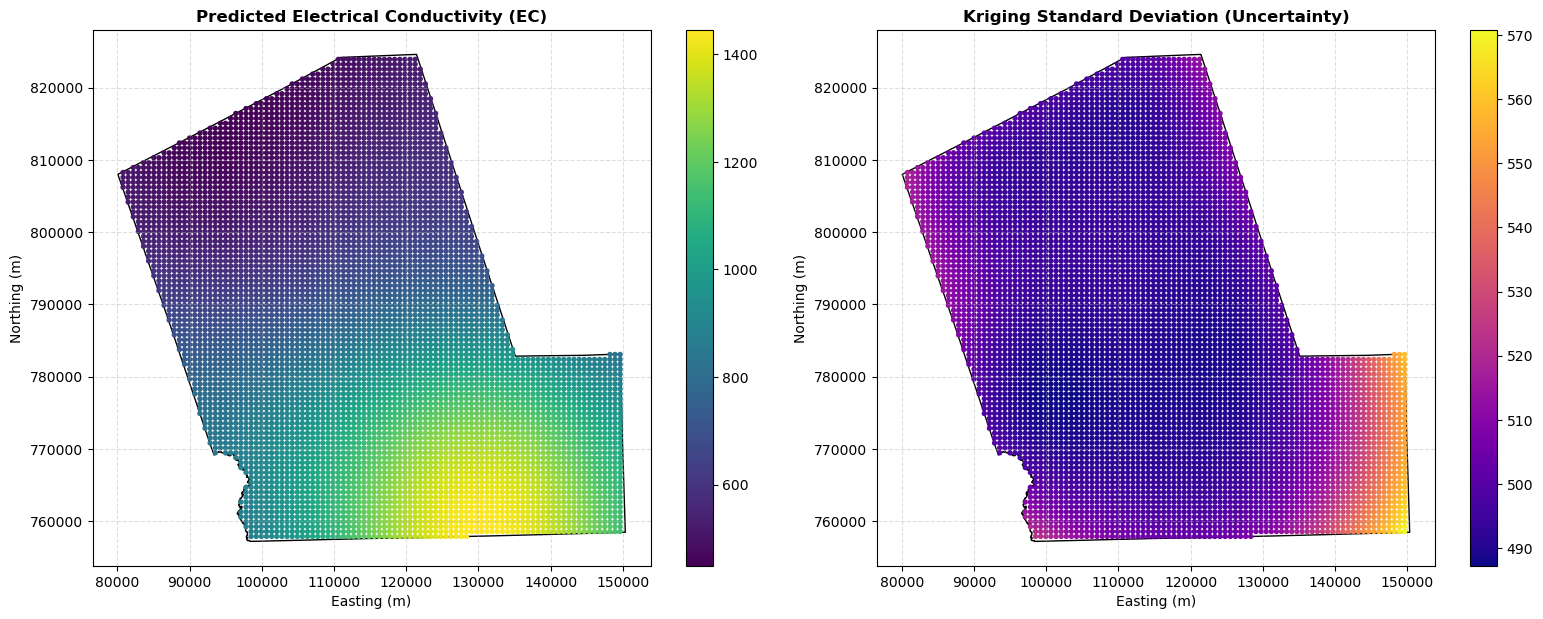

In [21]:
# PLOT PREDICTED EC AND UNCERTAINTY MAPS

fig, ax = plt.subplots(1, 2, figsize=(16, 6))                      # Create side-by-side figure

# Predicted EC map 
LibAEA.plot(ax=ax[0], facecolor='none', edgecolor='black')         # Plot Liberty County outline
LibEC_Kriging.plot(column="EC_pred", ax=ax[0],                     # Plot predicted EC (inside county)
                   cmap="viridis", markersize=8, legend=True)
ax[0].set_title("Predicted Electrical Conductivity (EC)", fontsize=12, weight="bold")  # Map title
ax[0].set_xlabel("Easting (m)")                                    # X-axis label
ax[0].set_ylabel("Northing (m)")                                   # Y-axis label
ax[0].grid(True, linestyle="--", alpha=0.4)                        # Add gridlines

# Uncertainty map (Standard Deviation)
LibAEA.plot(ax=ax[1], facecolor='none', edgecolor='black')         # Plot Liberty County outline
LibEC_Kriging.plot(column="EC_std", ax=ax[1],                      # Plot uncertainty inside county
                   cmap="plasma", markersize=8, legend=True)
ax[1].set_title("Kriging Standard Deviation (Uncertainty)", fontsize=12, weight="bold") # Map title
ax[1].set_xlabel("Easting (m)")                                    # X-axis label
ax[1].set_ylabel("Northing (m)")                                   # Y-axis label
ax[1].grid(True, linestyle="--", alpha=0.4)                        # Add gridlines
plt.tight_layout()                                                 # Adjust subplot layout
plt.show()                                                         # Display both maps


In [22]:
# INSTALL MAP ELEMENTS LIBRARIES

!pip install matplotlib-scalebar --quiet

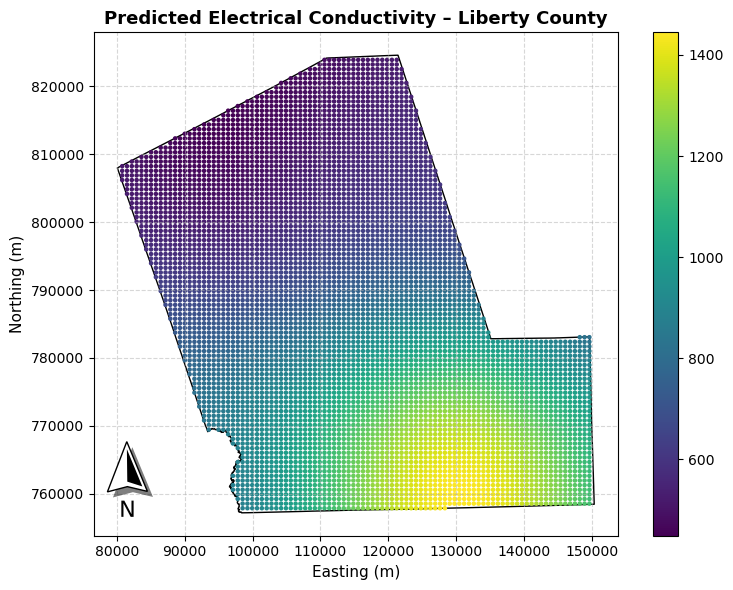

In [23]:
# PLOT CLIPPED KRIGING EC SURFACE 

fig, ax = plt.subplots(figsize=(8, 6))                                     # Create figure
LibAEA.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)        # County boundary
LibEC_Kriging.plot(ax=ax, column="EC_pred", cmap="viridis",                 # Predicted EC values
                   markersize=5, legend=True)
north_arrow(ax=ax, location="lower left", rotation={"crs": 5070, "reference": "center"}, scale=0.5)
ax.set_xlabel("Easting (m)", fontsize=11)
ax.set_ylabel("Northing (m)", fontsize=11)
ax.set_title("Predicted Electrical Conductivity – Liberty County", fontsize=13, weight="bold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [24]:
# EXPORT CLIPPED KRIGING RESULTS AS GEOPACKAGE

output_gpkg = "Liberty_EC_Kriging.gpkg"           # Output file name
LibEC_Kriging.to_file(output_gpkg, driver="GPKG")        # Save GeoDataFrame to GeoPackage

print(f"File saved as: {output_gpkg}")

File saved as: Liberty_EC_Kriging.gpkg


In [25]:
LibEC_Kriging.head()

,id,geometry,EC_pred,EC_var,EC_std
127,127,POINT (99233.682 757856.576),886.936386,272584.199547,522.095968
126,126,POINT (98524.026 757856.576),876.455995,274111.560677,523.556645
226,226,POINT (98524.026 758537.651),879.820700,271532.126910,521.087447
227,227,POINT (99233.682 758537.651),890.265092,270060.257761,519.673222
327,327,POINT (99233.682 759218.726),893.407115,267630.208693,517.329884
